In [96]:
!pip install opensignalsreader


In [97]:
from opensignalsreader import OpenSignalsReader
import matplotlib.pyplot as plt
import numpy as np

### PRIMERA SEÑAL

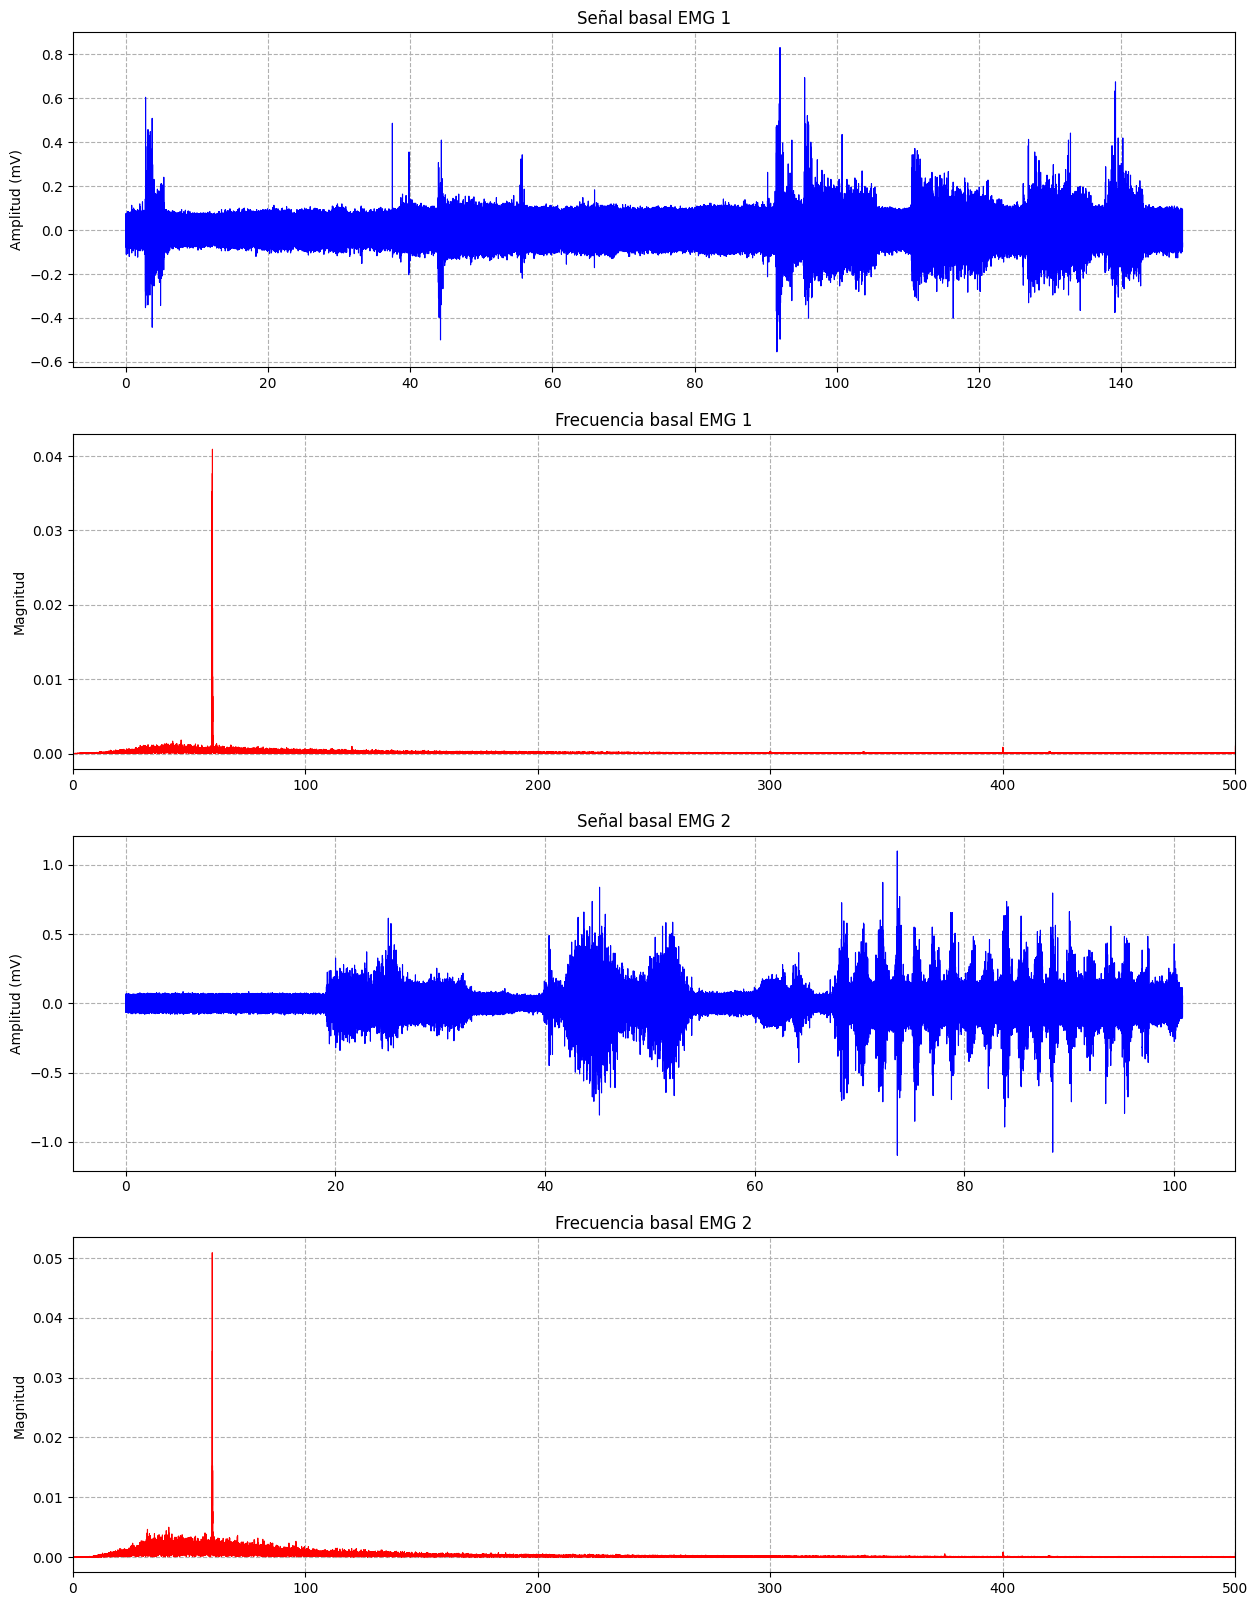

In [107]:
#Leemos el archivo que contiene las señales
acq1 = OpenSignalsReader('Prueba1_biceps.txt')
acq2 = OpenSignalsReader('Prueba2_biceps.txt')

#Extraemos la señal EMG del canal 1
emg_signal1 = acq1.signal(1)
emg_signal2 = acq2.signal(1)

#La frecuencia de muestreo establecida fue de 1000Hz
fs = 1000

#Procesamamos la señal para el dominio del tiempo
N1 = len(emg_signal1)
tiempo1 = np.arange(N1) / fs

N2 = len(emg_signal2)
tiempo2 = np.arange(N2) / fs

#Eliminamos la componente DC
emg_signal1 = emg_signal1 - np.mean(emg_signal1)
emg_signal2 = emg_signal2 - np.mean(emg_signal2)

#Pasamos al dominio de la frecuencia
fft_signal1 = (np.abs(np.fft.rfft(emg_signal1)) / N1) * 2
fft_signal1[0] /= 2

fft_signal2 = (np.abs(np.fft.rfft(emg_signal2)) / N2) * 2
fft_signal2[0] /= 2

#Ploteamos la señales
#Creamos los subplots para la grafica
figure, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(15, 20))

#Ploteamos la señal basal EMG
ax1.plot(tiempo1, emg_signal1, color='blue', linewidth=0.8)
ax1.set_title('Señal basal EMG 1')
ax1.set_ylabel('Amplitud (mV)')
ax1.grid(True, linestyle='--')

ax2.plot(freq_signal1, np.abs(fft_signal1), color='red', linewidth=0.8)
ax2.set_title('Frecuencia basal EMG 1')
ax2.set_ylabel('Magnitud')
ax2.set_xlim(0, 500)
ax2.grid(True, linestyle='--')

ax3.plot(tiempo2, emg_signal2, color='blue', linewidth=0.8)
ax3.set_title('Señal basal EMG 2')
ax3.set_ylabel('Amplitud (mV)')
ax3.grid(True, linestyle='--')

ax4.plot(freq_signal2, np.abs(fft_signal2), color='red', linewidth=0.8)
ax4.set_title('Frecuencia basal EMG 2')
ax4.set_ylabel('Magnitud')
ax4.set_xlim(0, 500)
ax4.grid(True, linestyle='--')